In [20]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

In [21]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'dynamic_tests': 1, 'static_tests': 1}

# IMPORTANDO DADOS

In [22]:
df_target = pd.read_csv('Target/output/data.csv')
df_target

,time,target_wx,target_tmp,target_wz,target_yaw,target_roll,target_az,target_wy,target_pitch,target_ax,target_ay
0,0.0,0.04551,60.2,0.12473,353.477,1.957,0.321011,0.35062,-4.358,-0.761653,9.788488
1,0.1,0.01124,60.5,-0.34067,353.484,1.958,0.319922,0.12805,-4.358,-0.778932,9.733845
2,0.2,-0.23899,60.5,0.02385,353.483,1.958,0.359247,-0.20591,-4.359,-0.783649,9.778113
3,0.3,-0.05959,60.2,-0.00802,353.484,1.957,0.368465,0.21019,-4.363,-0.683259,9.739553
4,0.4,-0.27809,60.5,0.21453,353.481,1.963,0.335211,-0.02057,-4.360,-0.700028,9.725775
...,...,...,...,...,...,...,...,...,...,...,...
669,66.9,-0.03999,60.5,0.30606,353.194,1.976,0.305663,0.11702,-4.356,-0.767027,9.752674
670,67.0,-0.08075,60.5,-0.22989,353.193,1.975,0.371741,0.09941,-4.357,-0.707471,9.720430
671,67.1,-0.15441,60.5,0.45741,353.194,1.975,0.327993,-0.04488,-4.356,-0.752111,9.777936
672,67.2,0.03487,60.5,-0.18754,353.196,1.975,0.361601,0.35198,-4.355,-0.733381,9.739112


In [23]:
df_ref = pd.read_csv('Reference/output/data.csv')
df_ref

,time,ref_wx,ref_wz,ref_yaw,ref_q1,ref_sample_time,ref_roll,ref_az,ref_q0,ref_q2,ref_la_pos_mon_d,ref_wy,ref_pitch,ref_ax,ref_q3,ref_ay
0,0.0,0.003031,-0.009672,-40.634167,0.6589,905000000.0,89.32412,-0.1157,0.6673,-0.2453,0.1645,-0.023193,-0.204145,0.03940,-0.2457,-9.788
1,0.1,0.004274,0.000688,-40.639896,0.6589,5000000.0,89.32412,-0.1158,0.6673,-0.2453,0.1647,-0.026769,-0.204145,0.03912,-0.2458,-9.788
2,0.2,-0.005924,0.001382,-40.639896,0.6589,105000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1650,-0.024528,-0.204374,0.03920,-0.2458,-9.788
3,0.3,0.007053,-0.007534,-40.639896,0.6589,205000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1652,-0.030487,-0.204374,0.03921,-0.2458,-9.788
4,0.4,-0.009752,-0.005117,-40.645626,0.6588,305000000.0,89.32412,-0.1157,0.6673,-0.2454,0.1655,-0.034956,-0.204546,0.03936,-0.2458,-9.788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,66.9,0.008021,-0.003244,-42.163964,0.6553,805000000.0,89.32412,-0.1144,0.6643,-0.2543,0.1323,-0.021251,-0.250898,0.04202,-0.2544,-9.788
670,67.0,-0.000432,0.007976,-42.169694,0.6553,905000000.0,89.32412,-0.1144,0.6642,-0.2543,0.1319,-0.025531,-0.251357,0.04224,-0.2544,-9.788
671,67.1,-0.020426,0.015722,-42.169694,0.6552,5000000.0,89.32412,-0.1142,0.6642,-0.2543,0.1316,-0.021056,-0.251357,0.04215,-0.2545,-9.788
672,67.2,0.013178,-0.008371,-42.175423,0.6552,105000000.0,89.32412,-0.1145,0.6642,-0.2543,0.1312,-0.018346,-0.251127,0.04204,-0.2545,-9.788


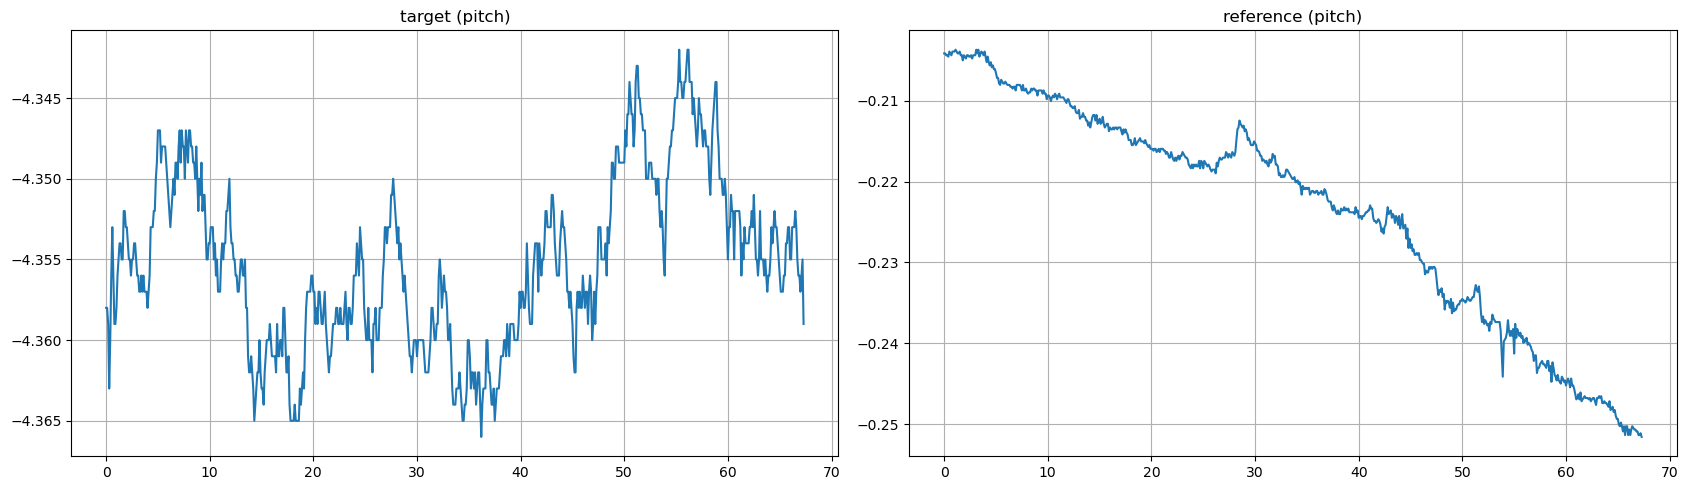

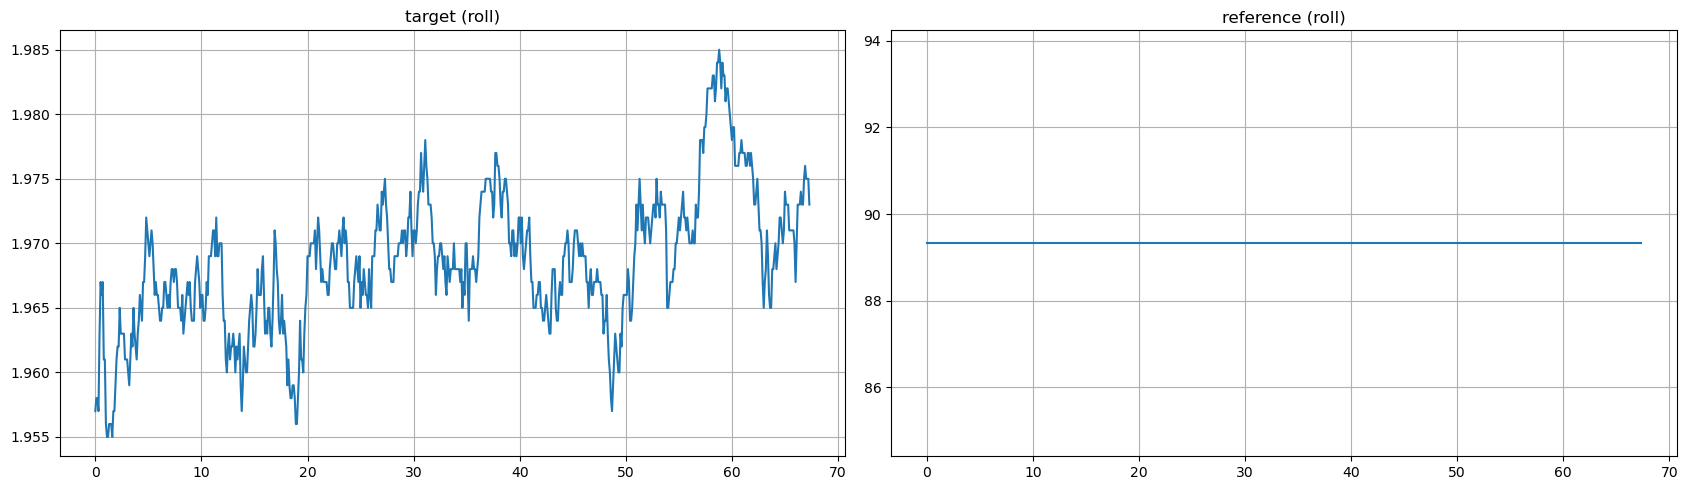

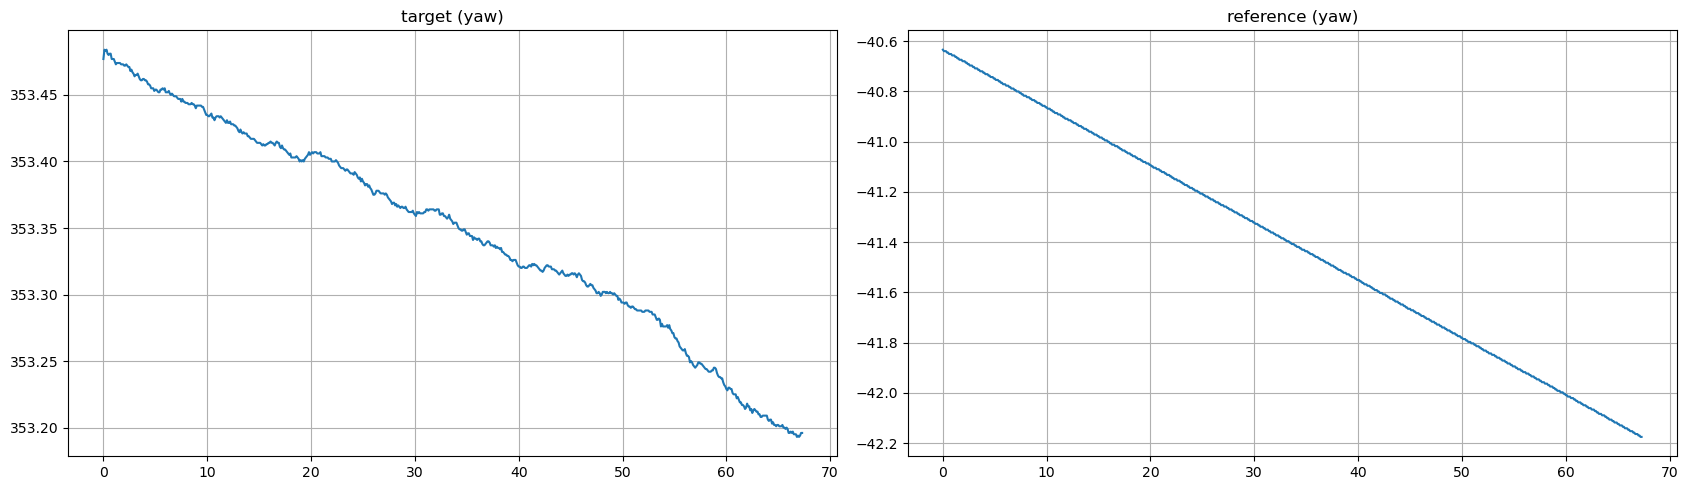

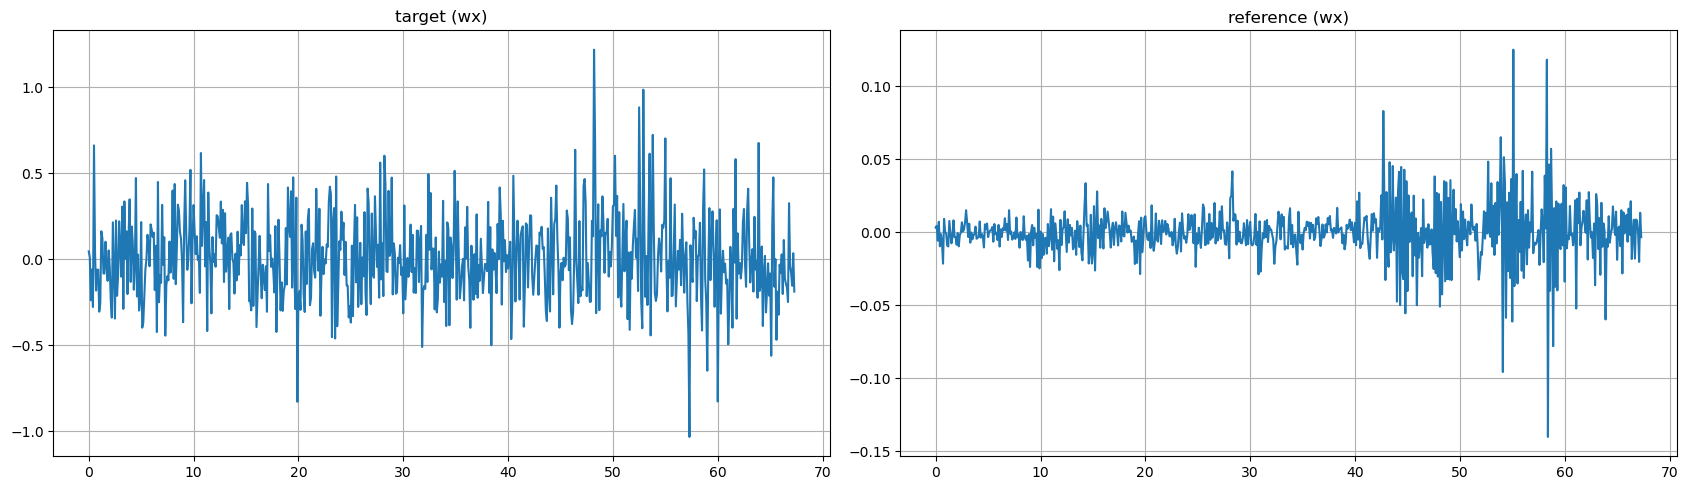

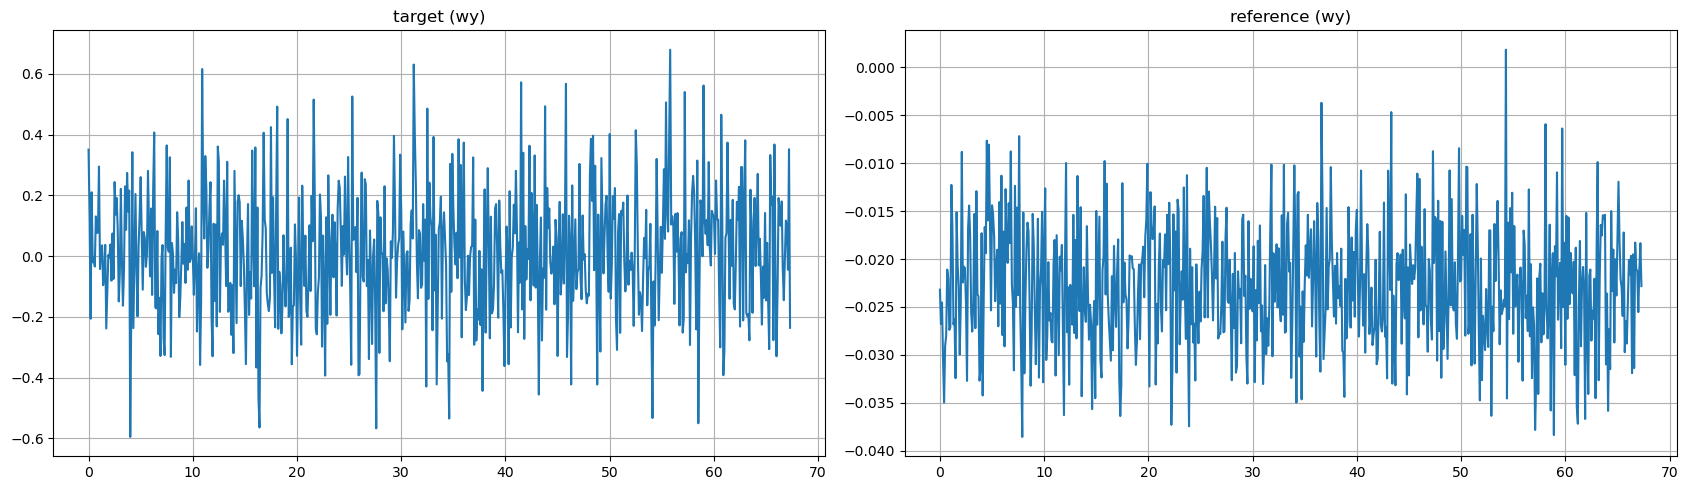

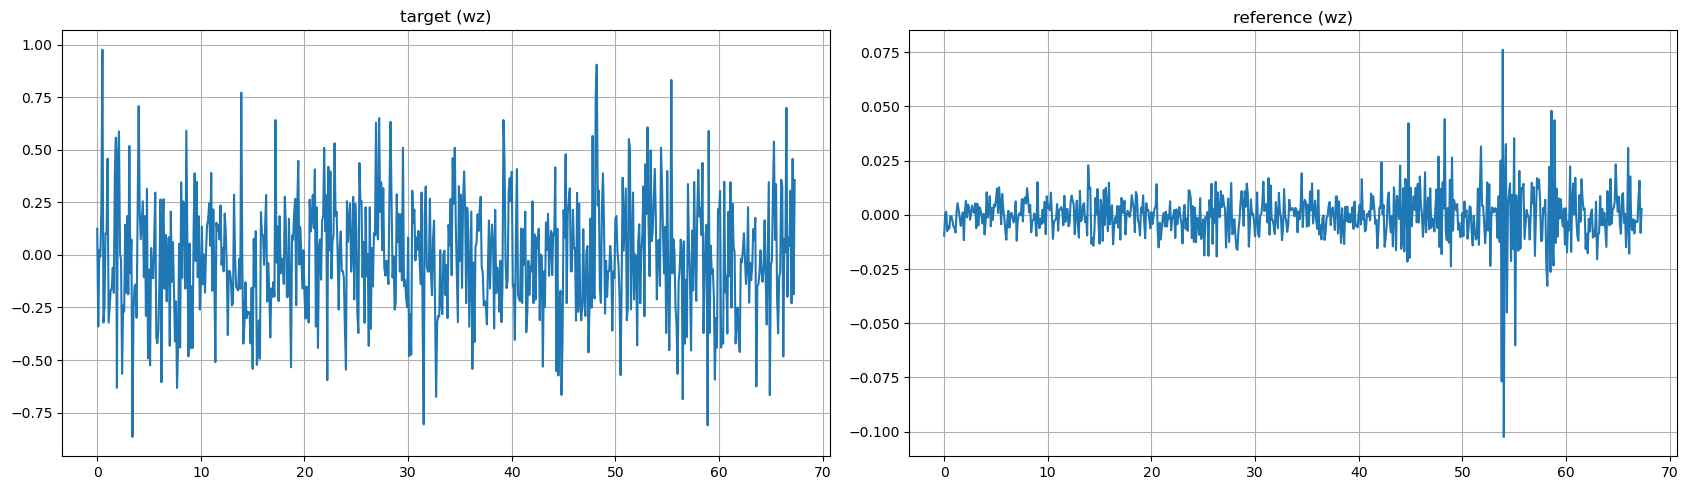

In [24]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target[f'target_{var}'], 
        f'reference ({var})': df_ref[f'ref_{var}']
    }, time=df_ref.time, figsize=(17, 5))

In [25]:
df = pd.merge_asof(df_target, df_ref, on='time', direction='nearest')
df

,time,target_wx,target_tmp,target_wz,target_yaw,target_roll,target_az,target_wy,target_pitch,target_ax,target_ay,ref_wx,ref_wz,ref_yaw,ref_q1,ref_sample_time,ref_roll,ref_az,ref_q0,ref_q2,ref_la_pos_mon_d,ref_wy,ref_pitch,ref_ax,ref_q3,ref_ay
0,0.0,0.04551,60.2,0.12473,353.477,1.957,0.321011,0.35062,-4.358,-0.761653,9.788488,0.003031,-0.009672,-40.634167,0.6589,905000000.0,89.32412,-0.1157,0.6673,-0.2453,0.1645,-0.023193,-0.204145,0.03940,-0.2457,-9.788
1,0.1,0.01124,60.5,-0.34067,353.484,1.958,0.319922,0.12805,-4.358,-0.778932,9.733845,0.004274,0.000688,-40.639896,0.6589,5000000.0,89.32412,-0.1158,0.6673,-0.2453,0.1647,-0.026769,-0.204145,0.03912,-0.2458,-9.788
2,0.2,-0.23899,60.5,0.02385,353.483,1.958,0.359247,-0.20591,-4.359,-0.783649,9.778113,-0.005924,0.001382,-40.639896,0.6589,105000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1650,-0.024528,-0.204374,0.03920,-0.2458,-9.788
3,0.3,-0.05959,60.2,-0.00802,353.484,1.957,0.368465,0.21019,-4.363,-0.683259,9.739553,0.007053,-0.007534,-40.639896,0.6589,205000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1652,-0.030487,-0.204374,0.03921,-0.2458,-9.788
4,0.4,-0.27809,60.5,0.21453,353.481,1.963,0.335211,-0.02057,-4.360,-0.700028,9.725775,-0.009752,-0.005117,-40.645626,0.6588,305000000.0,89.32412,-0.1157,0.6673,-0.2454,0.1655,-0.034956,-0.204546,0.03936,-0.2458,-9.788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,66.9,-0.03999,60.5,0.30606,353.194,1.976,0.305663,0.11702,-4.356,-0.767027,9.752674,0.008021,-0.003244,-42.163964,0.6553,805000000.0,89.32412,-0.1144,0.6643,-0.2543,0.1323,-0.021251,-0.250898,0.04202,-0.2544,-9.788
670,67.0,-0.08075,60.5,-0.22989,353.193,1.975,0.371741,0.09941,-4.357,-0.707471,9.720430,-0.000432,0.007976,-42.169694,0.6553,905000000.0,89.32412,-0.1144,0.6642,-0.2543,0.1319,-0.025531,-0.251357,0.04224,-0.2544,-9.788
671,67.1,-0.15441,60.5,0.45741,353.194,1.975,0.327993,-0.04488,-4.356,-0.752111,9.777936,-0.020426,0.015722,-42.169694,0.6552,5000000.0,89.32412,-0.1142,0.6642,-0.2543,0.1316,-0.021056,-0.251357,0.04215,-0.2545,-9.788
672,67.2,0.03487,60.5,-0.18754,353.196,1.975,0.361601,0.35198,-4.355,-0.733381,9.739112,0.013178,-0.008371,-42.175423,0.6552,105000000.0,89.32412,-0.1145,0.6642,-0.2543,0.1312,-0.018346,-0.251127,0.04204,-0.2545,-9.788


In [26]:
df.to_csv('output.csv', index=None)